# Decision 3 — Capital Adequacy under Vendor Uncertainty

**Mechanism.** Physical flood damage raises borrower PD and LGD, increasing expected
credit losses. These losses deplete the bank’s capital base, reducing the CET1 ratio.
The decision is threshold-based: post-stress CET1 below the regulatory minimum = breach.

**Transmission chain:**
```
d_iv → PD_iv = PD_0(1 + α d_iv),  LGD_iv = LGD_0 + λ d_iv
     → Loss_v = Σ_i EAD_i · PD_iv · LGD_iv − EL_0
     → CET1_v = (Capital_0 − Loss_v) / RWA_0
     → 1(CET1_v < CET1̅)
```
RWA is held fixed at baseline to isolate the capital-depletion channel.

In [23]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm as _norm
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
BLUE, RED, GREY, AMBER = '#4878CF', '#E84D0E', '#888888', '#F0A500'

In [36]:
# =============================================================================
# PARAMETERS — edit here to explore
# =============================================================================

PORTFOLIO_SEED = 42
VENDOR_SEED    = 1       # used for single-vendor diagnostic
N_DRAWS        = 100    # vendor draws for the RP200-shock CET1 distribution

# Reduced-form transmission
ALPHA              = 3.0       # PD amplification factor
PD_FUNCTIONAL_FORM = 'exponential'  # 'linear'      : PD(d) = PD0 * (1 + ALPHA * d)
                                # 'exponential' : PD(d) = PD0 * exp(ALPHA * d)
LAMBDA = 0.30                  # LGD(d) = LGD0 + LAMBDA * d

# Portfolio distributions
EAD_LOW,  EAD_HIGH  = 0.5,  5.0     # GBPm, Uniform
PD0_MU,   PD0_SIGMA = -5.52, 1.0    # LogNormal; median = 0.4%
LGD0_LOW, LGD0_HIGH = 0.20,  0.45   # Uniform

# Capital position (fixed — not derived from portfolio)
RWA_0       = 1000.0   # GBPm
CAPITAL_0   = 120.0    # GBPm  → baseline CET1 = 12.0%
CET1_HURDLE = 0.105    # 10.5% → 1.5 pp headroom

# Physical hazard simulation
N_VENDOR = 200     # vendor draws (outer loop)
N_MC     = 10_000  # annual flood scenarios per vendor draw (inner loop)
DEPENDENCE_SCENARIOS = {'Independent (rho=0)':   0.0,
                        'Partial dep. (rho=0.5)': 0.5,
                        'Full dep. (rho=1)':       1.0}

DATA_PATH = '../../data/raw/cfrf_garp_defended_flood.csv'

In [37]:
# =============================================================================
# DATA, PORTFOLIO AND CAPITAL CALIBRATION
# =============================================================================
df = pd.read_csv(DATA_PATH)
df.rename(columns={'minimim_dr': 'minimum_dr'}, inplace=True)
df = df.dropna(subset=['property_rank']).reset_index(drop=True)
n  = len(df)

tri_a = df['minimum_dr'].values.astype(float)
tri_b = df['maximum_dr'].values.astype(float)
tri_c = np.clip(3.0 * df['mean_dr'].values - tri_a - tri_b, tri_a, tri_b)

def tri_sample(rng, a, b, c):
    u     = rng.uniform(size=len(a))
    span  = np.where(b > a, b - a, 1.0)
    fc    = np.where(b > a, (c - a) / span, 0.0)
    left  = a + np.sqrt(np.maximum(u,     0) * span * np.maximum(c - a, 0))
    right = b - np.sqrt(np.maximum(1 - u, 0) * span * np.maximum(b - c, 0))
    return np.where(b > a, np.clip(np.where(u <= fc, left, right), 0, 1), a)

def stressed_pd(pd0, d):
    """Apply PD transmission; shape of pd0 and d must broadcast."""
    if PD_FUNCTIONAL_FORM == 'exponential':
        return np.clip(pd0 * np.exp(ALPHA * d), 1e-4, 0.9999)
    else:
        return np.clip(pd0 * (1.0 + ALPHA * d), 1e-4, 0.9999)

# Single vendor draw for diagnostic
d_vendor = tri_sample(np.random.default_rng(VENDOR_SEED), tri_a, tri_b, tri_c)

# Portfolio: draw per-loan EAD, PD0, LGD0
rng      = np.random.default_rng(PORTFOLIO_SEED)
ead      = rng.uniform(EAD_LOW, EAD_HIGH, n)
pd0_arr  = np.clip(
    stats.lognorm.rvs(PD0_SIGMA, scale=np.exp(PD0_MU), size=n,
                      random_state=int(rng.integers(2**31))),
    1e-4, 0.9999)
lgd0_arr = rng.uniform(LGD0_LOW, LGD0_HIGH, n)

# Capital position (fixed — not derived from portfolio)
threshold_loss = CAPITAL_0 - CET1_HURDLE * RWA_0   # GBP 15m

idx = np.argsort(df['mean_dr'].values)

print(f'n = {n} loans  |  Total EAD GBP{ead.sum():.1f}m')
print(f'Median PD0 = {np.median(pd0_arr)*100:.2f}%  |  '
      f'Median LGD0 = {np.median(lgd0_arr)*100:.1f}%')
print(f'PD form: {PD_FUNCTIONAL_FORM}  |  alpha={ALPHA}  lambda={LAMBDA}')
print(f'RWA_0 = {RWA_0:.0f}  |  Capital_0 = {CAPITAL_0:.0f}  |  '
      f'Baseline CET1 = {CAPITAL_0/RWA_0*100:.1f}%')
print(f'CET1 hurdle = {CET1_HURDLE*100:.1f}%  |  '
      f'Max loss before breach = GBP{threshold_loss:.1f}m')

n = 100 loans  |  Total EAD GBP269.0m
Median PD0 = 0.39%  |  Median LGD0 = 32.3%
PD form: exponential  |  alpha=3.0  lambda=0.3
RWA_0 = 1000  |  Capital_0 = 120  |  Baseline CET1 = 12.0%
CET1 hurdle = 10.5%  |  Max loss before breach = GBP15.0m


Vendor 1:  stressed EL GBP1.244m  |  CET1 23.751%  |  breach: False


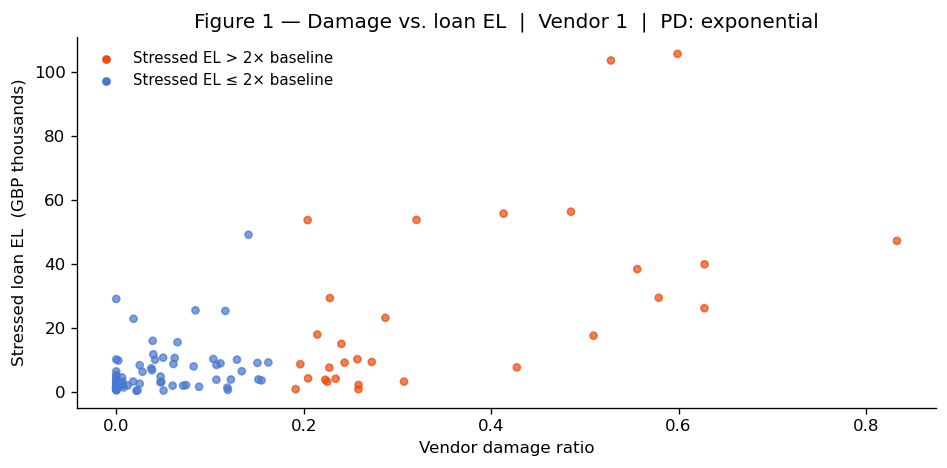

In [32]:
pd_v  = stressed_pd(pd0_arr, d_vendor)
lgd_v = np.minimum(lgd0_arr + LAMBDA * d_vendor, 1.0)
el_v  = ead * pd_v * lgd_v

Loss_v   = el_v.sum()
CET1_v   = (CAPITAL_0 - Loss_v) / RWA_0
breach_v = CET1_v < CET1_HURDLE

print(f'Vendor {VENDOR_SEED}:  stressed EL GBP{Loss_v:.3f}m  |  '
      f'CET1 {CET1_v*100:.3f}%  |  breach: {breach_v}')

fig, ax = plt.subplots(figsize=(8, 4))
above = el_v > ead * pd0_arr * lgd0_arr * 2
ax.scatter(d_vendor[idx], el_v[idx] * 1e3,
           c=np.where(above, RED, BLUE)[idx], s=18, alpha=0.7)
ax.scatter([], [], c=RED,  s=18, label='Stressed EL > 2× baseline')
ax.scatter([], [], c=BLUE, s=18, label='Stressed EL ≤ 2× baseline')
ax.set_xlabel('Vendor damage ratio')
ax.set_ylabel('Stressed loan EL  (GBP thousands)')
ax.set_title(f'Figure 1 — Damage vs. loan EL  |  Vendor {VENDOR_SEED}  '
             f'|  PD: {PD_FUNCTIONAL_FORM}')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

PD form: exponential  |  Breach probability: 0.00%  |  CET1 mean 23.752%  P5–P95: 23.687%–23.798%


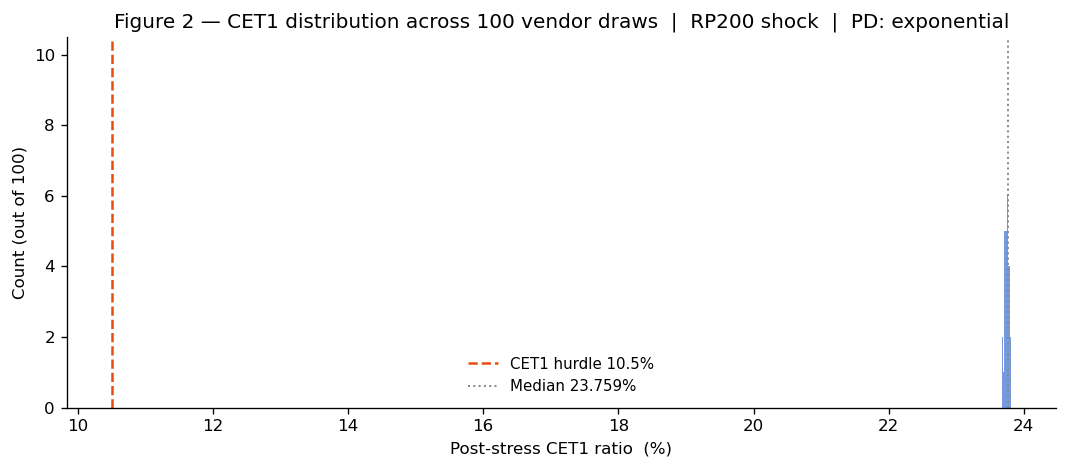

In [33]:
# N_DRAWS triangular samples — each represents one hypothetical vendor
_rng = np.random.default_rng(0)
u_m  = _rng.uniform(size=(N_DRAWS, n))
span = np.where(tri_b > tri_a, tri_b - tri_a, 1.0)
fc   = np.where(tri_b > tri_a, (tri_c - tri_a) / span, 0.0)
lft  = tri_a + np.sqrt(np.maximum(u_m,       0) * span * np.maximum(tri_c - tri_a, 0))
rgt  = tri_b - np.sqrt(np.maximum(1.0 - u_m, 0) * span * np.maximum(tri_b - tri_c, 0))
d_m  = np.where(tri_b > tri_a, np.clip(np.where(u_m <= fc, lft, rgt), 0, 1), tri_a)

pd_m   = stressed_pd(pd0_arr[None, :], d_m)
lgd_m  = np.minimum(lgd0_arr + LAMBDA * d_m, 1.0)
loss_v = (pd_m * lgd_m * ead).sum(axis=1)
cet1_v = (CAPITAL_0 - loss_v) / RWA_0
breach_v = cet1_v < CET1_HURDLE

print(f'PD form: {PD_FUNCTIONAL_FORM}  |  Breach probability: {breach_v.mean():.2%}  |  '
      f'CET1 mean {cet1_v.mean()*100:.3f}%  '
      f'P5–P95: {np.percentile(cet1_v,5)*100:.3f}%–{np.percentile(cet1_v,95)*100:.3f}%')

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(cet1_v.min() * 100, cet1_v.max() * 100, 60)
ax.hist(cet1_v * 100, bins=bins, color=BLUE, alpha=0.75, edgecolor='none')
for patch, b in zip(ax.patches, bins):
    if b < CET1_HURDLE * 100: patch.set_facecolor(RED)
ax.axvline(CET1_HURDLE * 100, color=RED, lw=1.5, ls='--',
           label=f'CET1 hurdle {CET1_HURDLE*100:.1f}%')
ax.axvline(np.median(cet1_v) * 100, color=GREY, lw=1.2, ls=':',
           label=f'Median {np.median(cet1_v)*100:.3f}%')
ax.set_xlabel('Post-stress CET1 ratio  (%)')
ax.set_ylabel(f'Count (out of {N_DRAWS})')
ax.set_title(f'Figure 2 — CET1 distribution across {N_DRAWS} vendor draws  '
             f'|  RP200 shock  |  PD: {PD_FUNCTIONAL_FORM}')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

Independent (rho=0)           median P99.5 = GBP0.660m  [P5=0.584, P95=0.933]
Partial dep. (rho=0.5)        median P99.5 = GBP0.679m  [P5=0.616, P95=0.998]
Full dep. (rho=1)             median P99.5 = GBP1.153m  [P5=0.934, P95=1.636]

Max loss before breach = GBP67.5m  (CET1 hurdle 10.5%)  |  PD form: exponential


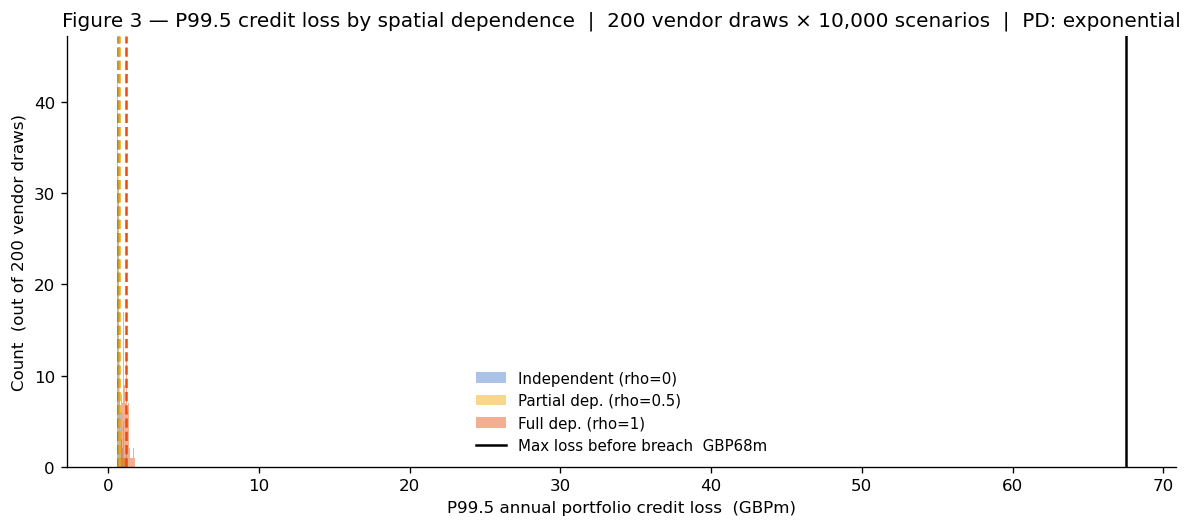

In [34]:
# Physical hazard simulation: for each of N_VENDOR vendor draws, run N_MC annual
# flood scenarios and record the P99.5 portfolio credit loss.
# Outer loop = vendor uncertainty; inner loop = physical hazard + spatial dependence.

def sample_p995(d_k, rho, rng):
    """P99.5 portfolio credit loss for vendor draw d_k under correlation rho."""
    N = N_MC
    if rho == 1.0:
        U = np.broadcast_to(rng.uniform(size=(N, 1)), (N, n)).copy()
    elif rho == 0.0:
        U = rng.uniform(size=(N, n))
    else:
        Z = rng.standard_normal(size=(N, 1))
        e = rng.standard_normal(size=(N, n))
        U = _norm.cdf(rho * Z + np.sqrt(1.0 - rho**2) * e)
    U    = np.maximum(U, 1e-10)
    d    = d_k[None, :] * np.clip((1.0 / U - 2.0) / 198.0, 0.0, 1.0)
    pd_  = stressed_pd(pd0_arr, d)
    lg_  = np.minimum(lgd0_arr + LAMBDA * d, 1.0)
    loss = (pd_ * lg_ * ead).sum(axis=1)
    return np.percentile(loss, 99.5)

# Pre-compute N_VENDOR triangular vendor draws
_rng_v = np.random.default_rng(0)
_u     = _rng_v.uniform(size=(N_VENDOR, n))
span   = np.where(tri_b > tri_a, tri_b - tri_a, 1.0)
fc     = np.where(tri_b > tri_a, (tri_c - tri_a) / span, 0.0)
lft    = tri_a + np.sqrt(np.maximum(_u,     0) * span * np.maximum(tri_c - tri_a, 0))
rgt    = tri_b - np.sqrt(np.maximum(1 - _u, 0) * span * np.maximum(tri_b - tri_c, 0))
d_vmat = np.where(tri_b > tri_a, np.clip(np.where(_u <= fc, lft, rgt), 0, 1), tri_a)

# Collect P99.5 for each vendor × dependence scenario
p995 = {}
for label, rho in DEPENDENCE_SCENARIOS.items():
    _rng_mc = np.random.default_rng(42)
    p995[label] = np.array([sample_p995(d_vmat[k], rho, _rng_mc)
                             for k in range(N_VENDOR)])
    print(f'{label:28s}  median P99.5 = GBP{np.median(p995[label]):.3f}m  '
          f'[P5={np.percentile(p995[label],5):.3f}, P95={np.percentile(p995[label],95):.3f}]')

print(f'\nMax loss before breach = GBP{threshold_loss:.1f}m  '
      f'(CET1 hurdle {CET1_HURDLE*100:.1f}%)  |  PD form: {PD_FUNCTIONAL_FORM}')

# Overlaid histograms
colours_dep = [BLUE, AMBER, RED]
all_vals = np.concatenate(list(p995.values()))
bins = np.linspace(np.percentile(all_vals, 0.5), np.percentile(all_vals, 99.5), 50)

fig, ax = plt.subplots(figsize=(10, 4.5))
for (label, vals), col in zip(p995.items(), colours_dep):
    ax.hist(vals, bins=bins, color=col, alpha=0.45, edgecolor='none', label=label)
    ax.axvline(np.median(vals), color=col, lw=1.5, ls='--')
ax.axvline(threshold_loss, color='black', lw=1.5, ls='-',
           label=f'Max loss before breach  GBP{threshold_loss:.0f}m')
ax.set_xlabel('P99.5 annual portfolio credit loss  (GBPm)')
ax.set_ylabel(f'Count  (out of {N_VENDOR} vendor draws)')
ax.set_title(f'Figure 3 — P99.5 credit loss by spatial dependence'
             f'  |  {N_VENDOR} vendor draws × {N_MC:,} scenarios  '
             f'|  PD: {PD_FUNCTIONAL_FORM}')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

In [35]:
print('=== Decision 3 summary ===')
print(f'RWA_0={RWA_0:.0f}  Capital_0={CAPITAL_0:.0f}  '
      f'Baseline CET1={CAPITAL_0/RWA_0*100:.1f}%  Hurdle={CET1_HURDLE*100:.1f}%')
print(f'Max loss before breach = GBP{threshold_loss:.1f}m')
print(f'Baseline EL = GBP{(ead*PD0*LGD0).sum():.3f}m  |  '
      f'PD0={PD0*100:.1f}%  LGD0={LGD0*100:.0f}%  alpha={ALPHA}  lambda={LAMBDA}')
print(f'\nVendor-only (RP200 shock, N={N_DRAWS}):  '
      f'breach {breach_v.mean():.2%}  '
      f'CET1 {np.percentile(cet1_v,5)*100:.3f}–{np.percentile(cet1_v,95)*100:.3f}%')
print(f'\nPhysical hazard (N_VENDOR={N_VENDOR}, N_MC={N_MC:,}):')
for label, vals in p995.items():
    cet1_p995 = (CAPITAL_0 - vals) / RWA_0
    breach_p995 = (vals > threshold_loss).mean()
    print(f'  {label:28s}  median P99.5 loss = GBP{np.median(vals):.3f}m  '
          f'CET1 = {np.median(cet1_p995)*100:.3f}%  '
          f'breach share = {breach_p995:.2%}')

=== Decision 3 summary ===
RWA_0=500  Capital_0=120  Baseline CET1=24.0%  Hurdle=10.5%
Max loss before breach = GBP67.5m


NameError: name 'PD0' is not defined